# Arrow Sudoku

In [1]:
import pulp as plp

## What is Arrow Sudoku?


In addition to the standard Sudoku rules, in Arrow Sudoku the digits in the circled cells must be the sum of the digits along the arrow point out of it. 

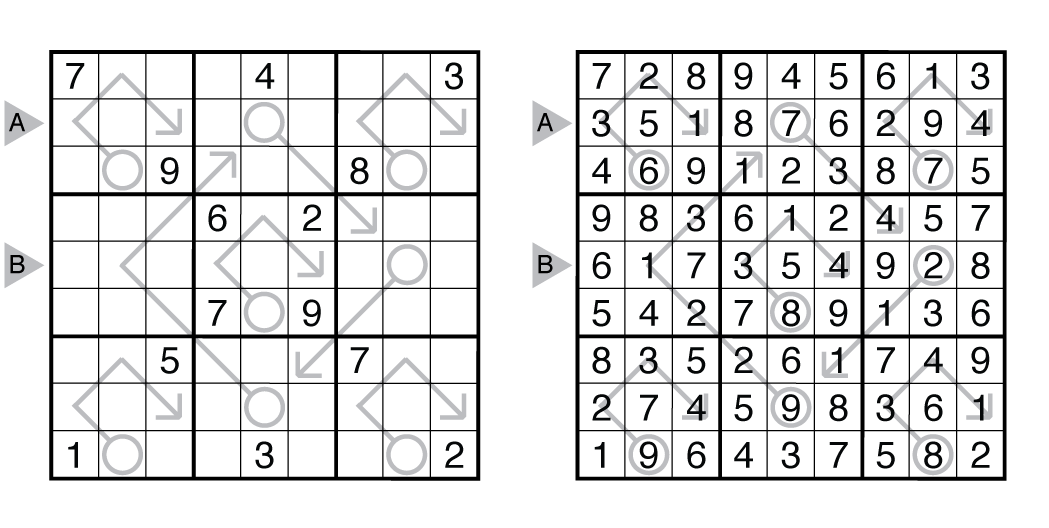

## Problem Statement

### Decision Variables:
- $i$: row index
- $j$: column index
- $v$: value of the cel
- $G_{ijv}$: Grid variable at row $i$, column $j$ with value $v$.
  
$G_{ijv} \in \{0, 1\}$ for row,col:  $i,j \in \{0 ... 8\}$, value: $ v\in \{1...9\}$.

Binary variable = 1 if cell (row,col) contains digit 'value', 0 otherwise.

### Normal Sudoku Constraints:
#### 1. Cell uniqueness: Each cell should contain only 1 value.

For each $(i,j)$:
$$\sum_{v=1}^{9} G_{ijv} = 1$$


In [ ]:
for row in rows:
        for col in cols:
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value] for value in values]),
                                        sense=plp.LpConstraintEQ, rhs=1, name=f"constraint_sum_{row}_{col}"))

#### 2. Row uniqueness: For each row, numbers 1 to 9 can appear only once.

For each row and each value v:
       $$\sum_{col=0}^{8} G_{ijv} \cdot v = v$$


In [ ]:
for row in rows:
        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for col in cols]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_row_{row}_{value}"))

#### 3. Column uniqueness: For each column, numbers from 1 to 9 can appear only once.

For each col and each value v:
       $$\sum_{row=0}^{8} G_{ijv} \cdot v = v$$

In [ ]:
for col in cols:
        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for row in rows]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_col_{col}_{value}"))

#### 4. Box uniqueness:  For each 3×3 box, numbers from 1 to 9 can appear only once.

For each box and value:
$$\sum_{(i,j) \text{ in box}} G_{ijv} \cdot v = v$$


In [ ]:
for grid in grids:
        grid_row  = int(grid/3)
        grid_col  = int(grid%3)

        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[grid_row*3+row][grid_col*3+col][value]*value  for col in range(0,3) for row in range(0,3)]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_grid_{grid}_{value}"))

#### 5. Prefilled cells: The prefilled cells should have the same value with the prefilled value.

For each given cell (row, col) with known digit d:
$$\sum_{v=1}^{9} G_{ij v}\cdot v = d$$
where $d$ is the prefilled value of the cell.

In [ ]:
for row in rows:
        for col in cols:
            if(input_sudoku[row][col] != 0):
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for value in values]), 
                                                    sense=plp.LpConstraintEQ, 
                                                    rhs=input_sudoku[row][col],
                                                    name=f"constraint_prefilled_{row}_{col}"))

### Arrow Sudoku Constraints:


Let $A$ be the set of all arrows in the sudoku and $a \in A$. 

- The base of the arrow (containing the sum of thew arrow) be denoted by the pair $(c_r,c_c)$ where $c_r$ and $c_c$ represent circle row and column respectively.
- The path of the arrow is denoted by the set $P_a = \{(p_{c}^{1},p_{r}^{1}),(p_{c}^{2},p_{r}^{2}),...,(p_{c}^{n},p_{r}^{n})\}$ where $p^n$ denotes each cell on the arrow's path and the pair $(p_{c}^{n},p_{r}^{n})$ denotes the row and column of $p^n$.

For each arrow, the circle should contains the sum of all the numbers on the arrow's path. So the constraint for each arrow:

$$\sum_{v=1}^{9} v \cdot G_{c_r,\, c_c,\, v} \;=\; \sum_{(p_r^k,\, p_c^k) \in P_a} \;\sum_{v=1}^{9} v \cdot G_{p_r^k,\, p_c^k,\, v} \qquad \forall \; a \in A$$

Or in standard LP form:

$$\sum_{v=1}^{9} v \cdot G_{c_r,\, c_c,\, v} \;-\; \sum_{(p_r^k,\, p_c^k) \in P_a} \;\sum_{v=1}^{9} v \cdot G_{p_r^k,\, p_c^k,\, v} \;=\; 0 \qquad \forall \; a \in A$$


In [ ]:
for idx, arrow in enumerate(arrows):
        cr, cc = arrow["circle"]
        path = arrow["path"]

        circle_value = plp.lpSum(
            [grid_vars[cr][cc][v] * v for v in values]
        )

        path_sum = plp.lpSum(
            [grid_vars[pr][pc][v] * v for (pr, pc) in path for v in values]
        )

        prob.addConstraint(
            plp.LpConstraint(
                e=circle_value - path_sum,
                sense=plp.LpConstraintEQ,
                rhs=0,
                name=f"constraint_arrow_{idx}",
            )
        )

## Building the Solver
### Constraint Functions

In [26]:
def add_default_sudoku_constraints(prob, grid_vars, rows, cols, grids, values):
    
    # Constraint to ensure only one value is filled for a cell
    for row in rows:
        for col in cols:
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value] for value in values]),
                                        sense=plp.LpConstraintEQ, rhs=1, name=f"constraint_sum_{row}_{col}"))


    # Constraint to ensure that values from 1 to 9 is filled only once in a row        
    for row in rows:
        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for col in cols]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_row_{row}_{value}"))

    # Constraint to ensure that values from 1 to 9 is filled only once in a column        
    for col in cols:
        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for row in rows]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_col_{col}_{value}"))


    # Constraint to ensure that values from 1 to 9 is filled only once in the 3x3 grid       
    for grid in grids:
        grid_row  = int(grid/3)
        grid_col  = int(grid%3)

        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[grid_row*3+row][grid_col*3+col][value]*value  for col in range(0,3) for row in range(0,3)]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_grid_{grid}_{value}"))

In [27]:
# Prefilled values
def add_prefilled_constraints(prob, input_sudoku, grid_vars, rows, cols, values):
    for row in rows:
        for col in cols:
            if(input_sudoku[row][col] != 0):
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for value in values]), 
                                                    sense=plp.LpConstraintEQ, 
                                                    rhs=input_sudoku[row][col],
                                                    name=f"constraint_prefilled_{row}_{col}"))

In [28]:
# Arrow Constraint
def add_arrow_constraints(prob, grid_vars, arrows, values):

    for idx, arrow in enumerate(arrows):
        cr, cc = arrow["circle"]
        path = arrow["path"]

        circle_value = plp.lpSum(
            [grid_vars[cr][cc][v] * v for v in values]
        )

        path_sum = plp.lpSum(
            [grid_vars[pr][pc][v] * v for (pr, pc) in path for v in values]
        )

        prob.addConstraint(
            plp.LpConstraint(
                e=circle_value - path_sum,
                sense=plp.LpConstraintEQ,
                rhs=0,
                name=f"constraint_arrow_{idx}",
            )
        )


### Printing Solutions Helper Functions 

In [32]:
def extract_solution(grid_vars, rows, cols, values):
    solution = [[0 for col in cols] for row in rows]
    for row in rows:
        for col in cols:
            for value in values:
                if plp.value(grid_vars[row][col][value]):
                    solution[row][col] = value
    return solution


def print_solution(solution, rows, cols):
    print(f"\nFinal result:")
    print("\n\n+ ----------- + ----------- + ----------- +", end="")
    for row in rows:
        print("\n", end="\n|  ")
        for col in cols:
            num_end = "  |  " if ((col + 1) % 3 == 0) else "   "
            print(solution[row][col], end=num_end)
        if (row + 1) % 3 == 0:
            print("\n\n+ ----------- + ----------- + ----------- +", end="")
    print()


def print_arrows_verification(solution, arrows):
    print("\n--- Arrow Constraint Verification ---")
    all_valid = True
    for idx, arrow in enumerate(arrows):
        cr, cc = arrow["circle"]
        path = arrow["path"]
        circle_val = solution[cr][cc]
        path_vals = [solution[sr][sc] for (sr, sc) in path]
        path_sum = sum(path_vals)
        valid = "+" if circle_val == path_sum else "-"
        if circle_val != path_sum:
            all_valid = False
        print(
            f"  Arrow {idx}: circle({cr},{cc})={circle_val}  "
            f"path={path_vals} sum={path_sum}  [{valid}]"
        )
    if all_valid:
        print("  All arrow constraints satisfied!")
    else:
        print("  Some arrow constraints are violated!")

def print_solution_with_arrows(solution, rows, cols, arrows):
    
    COLORS = [
        "\033[91m",        # 0: red
        "\033[92m",        # 1: green
        "\033[94m",        # 2: blue
        "\033[93m",        # 3: yellow
        "\033[95m",        # 4: magenta
        "\033[96m",        # 5: cyan
        "\033[38;5;208m",  # 6: orange
        "\033[38;5;177m",  # 7: purple
        "\033[38;5;82m",   # 8: lime
        "\033[38;5;197m",  # 9: pink
    ]
    RESET = "\033[0m"
    BOLD = "\033[1m"
    
    cell_info = {}
    for idx, arrow in enumerate(arrows):
        cr, cc = arrow["circle"]
        cell_info[(cr, cc)] = ("circle", idx)
        for (pr, pc) in arrow["path"]:
            if (pr, pc) not in cell_info:
                cell_info[(pr, pc)] = ("path", idx)
    
    print(f"\nFinal result:\n")
    print("+ ----------- + ----------- + ----------- +")
    
    for row in rows:
        line = "|"
        for col in cols:
            val = solution[row][col]
            if (row, col) in cell_info:
                ctype, aidx = cell_info[(row, col)]
                color = COLORS[aidx % len(COLORS)]
                if ctype == "circle":
                    cell_str = f" {color}{BOLD}({val}){RESET}"
                else:
                    cell_str = f" {color}{BOLD} {val} {RESET}"
            else:
                cell_str = f"  {val} "
            if (col + 1) % 3 == 0:
                line += cell_str + " |"
            else:
                line += cell_str
        print(line)
        if (row + 1) % 3 == 0:
            print("+ ----------- + ----------- + ----------- +")
    
    print()
    print("(n) = circle cell, same color = same arrow")
    print()
    for idx, arrow in enumerate(arrows):
        cr, cc = arrow["circle"]
        color = COLORS[idx % len(COLORS)]
        circle_val = solution[cr][cc]
        path_vals = [solution[pr][pc] for (pr, pc) in arrow["path"]]
        print(f"  {color}{BOLD}Arrow {idx}: ({circle_val})"
              f"  =  {' + '.join(str(v) for v in path_vals)}"
              f"  =  {sum(path_vals)}{RESET}")
        
def print_input_with_arrows(input_sudoku, rows, cols, arrows):
    
    COLORS = [
        "\033[91m",        # 0: red
        "\033[92m",        # 1: green
        "\033[94m",        # 2: blue
        "\033[93m",        # 3: yellow
        "\033[95m",        # 4: magenta
        "\033[96m",        # 5: cyan
        "\033[38;5;208m",  # 6: orange
        "\033[38;5;177m",  # 7: purple
        "\033[38;5;82m",   # 8: lime
        "\033[38;5;197m",  # 9: pink
    ]
    RESET = "\033[0m"
    BOLD = "\033[1m"
    
    cell_info = {}
    for idx, arrow in enumerate(arrows):
        cr, cc = arrow["circle"]
        cell_info[(cr, cc)] = ("circle", idx)
        for (pr, pc) in arrow["path"]:
            if (pr, pc) not in cell_info:
                cell_info[(pr, pc)] = ("path", idx)
    
    print(f"\nInput Arrow Sudoku:\n")
    print("+ ----------- + ----------- + ----------- +")
    
    for row in rows:
        line = "|"
        for col in cols:
            val = input_sudoku[row][col]
            
            if (row, col) in cell_info:
                ctype, aidx = cell_info[(row, col)]
                color = COLORS[aidx % len(COLORS)]
                if ctype == "circle":
                    if val != 0:
                        cell_str = f" {color}{BOLD}({val}){RESET}"
                    else:
                        cell_str = f" {color}{BOLD}( ){RESET}"
                else:
                    if val != 0:
                        cell_str = f" {color}{BOLD} {val} {RESET}"
                    else:
                        cell_str = f" {color}{BOLD} * {RESET}"
            else:
                if val != 0:
                    cell_str = f"  {val} "
                else:
                    cell_str = f"    "
            
            if (col + 1) % 3 == 0:
                line += cell_str + " |"
            else:
                line += cell_str
        print(line)
        if (row + 1) % 3 == 0:
            print("+ ----------- + ----------- + ----------- +")
    
    print()
    print("( ) = circle cell, * = path cell, same color = same arrow")
    print()
    for idx, arrow in enumerate(arrows):
        cr, cc = arrow["circle"]
        color = COLORS[idx % len(COLORS)]
        path = arrow["path"]
        print(f"  {color}{BOLD}Arrow {idx}: circle=({cr},{cc})"
              f" → path={path}{RESET}")

### Solving the Problem

In [33]:
def solve_arrow_sudoku(input_sudoku, arrows):

    prob = plp.LpProblem("Arrow_Sudoku_Solver")

    rows = range(0, 9)
    cols = range(0, 9)
    grids = range(0, 9)
    values = range(1, 10)

    # Decision Variables
    grid_vars = plp.LpVariable.dicts("grid_value", (rows, cols, values), cat="Binary")

    # Objective Function
    objective = plp.lpSum(0)
    prob.setObjective(objective)

    # Normal Sudoku Constraints
    add_default_sudoku_constraints(prob, grid_vars, rows, cols, grids, values)

    # Prefilled Values
    add_prefilled_constraints(prob, input_sudoku, grid_vars, rows, cols, values)

    # Arrow Sudoku Constraints
    add_arrow_constraints(prob, grid_vars, arrows, values)

    prob.solve()

    solution_status = plp.LpStatus[prob.status]
    print(f"Solution Status = {solution_status}")

    if solution_status == "Optimal":
        print_input_with_arrows(input_sudoku, rows, cols, arrows)
        solution = extract_solution(grid_vars, rows, cols, values)
        print_solution_with_arrows(solution, rows, cols, arrows)
        print_arrows_verification(solution, arrows)
        return solution
    else:
        print("No feasible solution found.")
        return None

### Example Arrow Sudoku

In [34]:
if __name__ == "__main__":

    arrow_sudoku = [
        [7, 0, 0, 0, 4, 0, 0, 0, 3],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 9, 0, 0, 0, 8, 0, 0],
        [0, 0, 0, 6, 0, 2, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 7, 0, 9, 0, 0, 0],
        [0, 0, 5, 0, 0, 0, 7, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 3, 0, 0, 0, 2],
    ]

    arrows = [
        {"circle": (2,1), "path": [(1, 0),(0,1),(1,2)]},
        {"circle": (1,4), "path": [(2,5),(3,6)]},
        {"circle": (2,7), "path": [(1,6),(0,7),(1,8)]},
        {"circle": (5,4), "path": [(4, 3), (3,4),(4,5)]},
        {"circle": (4,7), "path": [(5, 6),(6,5)]},
        {"circle": (8,1), "path": [(7,0),(6,1),(7,2)]},
        {"circle": (7,4), "path": [(6,3),(5,2),(4,1),(3,2),(2,3)]},
        {"circle": (8,7), "path": [(7,6),(6,7),(7,8)]},
    ]

    print("  ARROW SUDOKU SOLVER")
    print("-" * 60)
    

    solve_arrow_sudoku(arrow_sudoku, arrows)

  ARROW SUDOKU SOLVER
------------------------------------------------------------
GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --cpxlp /tmp/321927e0e7bb4c42a68a2b065830c6cd-pulp.lp -o /tmp/321927e0e7bb4c42a68a2b065830c6cd-pulp.sol
Reading problem data from '/tmp/321927e0e7bb4c42a68a2b065830c6cd-pulp.lp'...
346 rows, 730 columns, 3330 non-zeros
729 integer variables, all of which are binary
2083 lines were read
GLPK Integer Optimizer 5.0
346 rows, 730 columns, 3330 non-zeros
729 integer variables, all of which are binary
Preprocessing...
321 rows, 575 columns, 2608 non-zeros
575 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  9.000e+00  ratio =  9.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 229
Solving LP relaxation...
GLPK Simplex Optimizer 5.0
321 rows, 575 columns, 2608 non-zeros
      0: obj =   0.000000000e+00 inf =   3.877e+02 (87)
    432: obj =   